In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.15.0


In [3]:
# Konfigurasi
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = [
    'Blackheads',
    'Cyst',
    'Papules',
    'Pustules',
    'Whiteheads'
]
NUM_CLASSES = len(CLASS_NAMES)

DATASET_DIR = "AcneDataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VALID_DIR = os.path.join(DATASET_DIR, "valid")
TEST_DIR  = os.path.join(DATASET_DIR, "test")
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [4]:
# Eksplorasi Struktur Dataset
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATASET_DIR, split)
    print(f"\n{split.upper()} Data")  

    total_images = 0
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            total_images += num_images
            print(f"{class_name}: {num_images} images")
    
    print(f"Total: {total_images} images")


TRAIN Data
Blackheads: 735 images
Cyst: 645 images
Papules: 621 images
Pustules: 584 images
Whiteheads: 193 images
Total: 2778 images

VALID Data
Blackheads: 240 images
Cyst: 206 images
Papules: 209 images
Pustules: 217 images
Whiteheads: 49 images
Total: 921 images

TEST Data
Blackheads: 265 images
Cyst: 189 images
Papules: 202 images
Pustules: 205 images
Whiteheads: 57 images
Total: 918 images


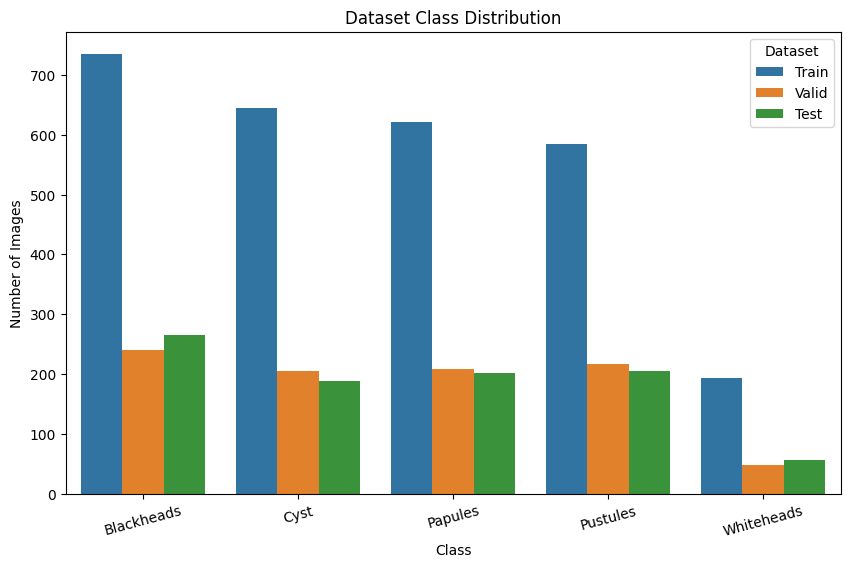

In [5]:
# Distribusi Kelas  
splits = {
    "Train": TRAIN_DIR,
    "Valid": VALID_DIR,
    "Test": TEST_DIR
}

distribution_data = []
for split_name, split_path in splits.items():
    for class_name in CLASS_NAMES:
        class_path = os.path.join(
            split_path,
            class_name
        )
        num_images = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(
                ('.png', '.jpg', '.jpeg')
            )
        ])
        distribution_data.append({
            "Dataset": split_name,
            "Class": class_name,
            "Count": num_images
        })

distribution_df = pd.DataFrame(distribution_data)
plt.figure(figsize=(10,6))

sns.barplot(
    data=distribution_df,
    x="Class",
    y="Count",
    hue="Dataset"
)

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

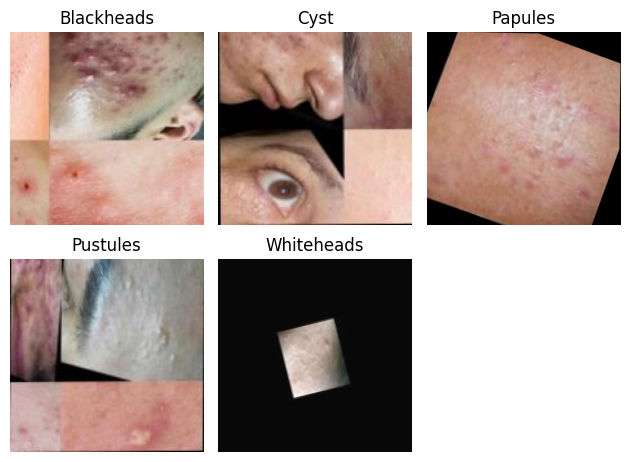

In [6]:
# Visualisasi
for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    image = Image.open(image_path)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
print(image.size)

(640, 640)


In [8]:
# Load Dataset
train_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)
 
valid_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
 
test_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2778 files belonging to 5 classes.
Found 921 files belonging to 5 classes.
Found 918 files belonging to 5 classes.


In [9]:
class_names = train_raw.class_names
print("Class Names:", class_names)

Class Names: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


In [10]:
# Augementasi (Sementara Global)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    ], name="augmentation")

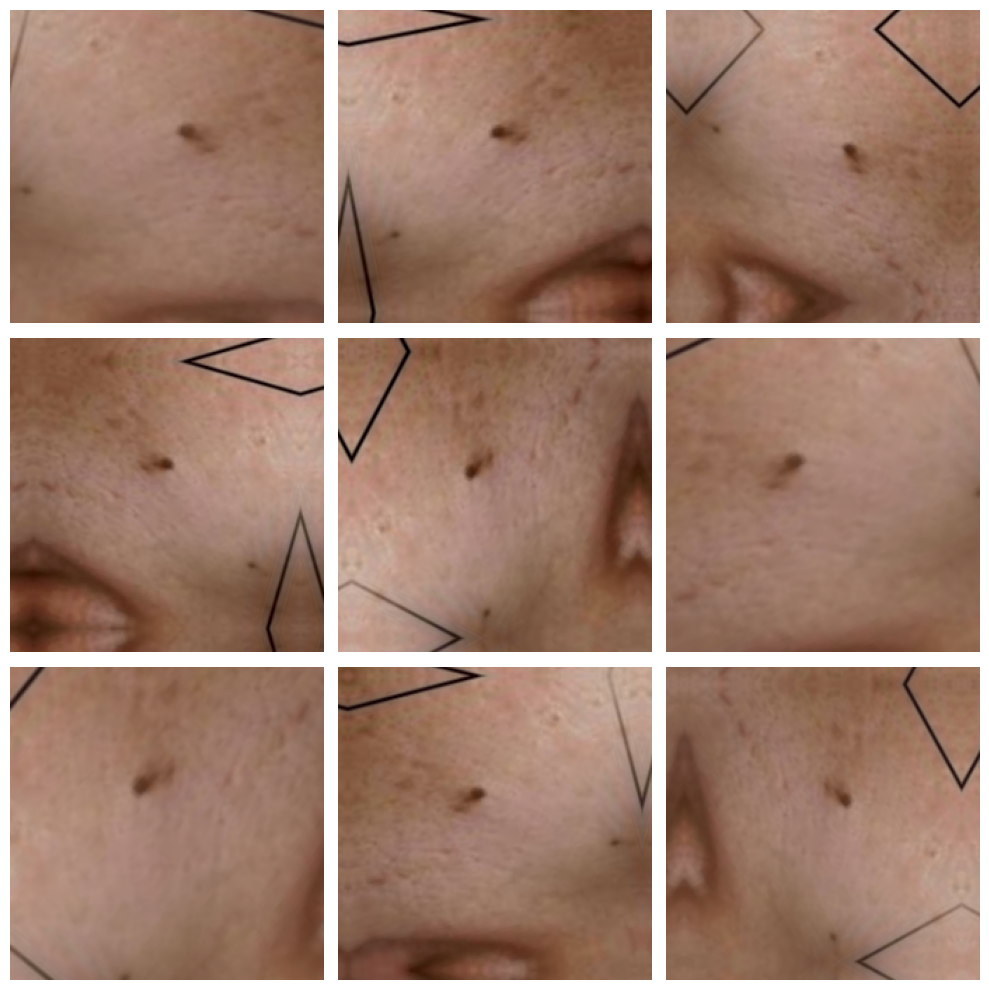

In [11]:
# Visualisasi Augmentasi
for images, labels in train_raw.take(1):
    sample_image = images[0]
    plt.figure(figsize=(10,10))

    for i in range(9):     
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )
        plt.subplot(3,3,i+1)
        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [12]:
# Normalisasi
normalization_layer = layers.Rescaling(1./255)

In [13]:
# Preprocessing 
train_cnn = train_raw.map(
    lambda x, y: (
        normalization_layer(
            data_augmentation(
                x, training=True)), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)
 
valid_cnn = valid_raw.map(
    lambda x, y: (
        normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)
 
test_cnn = test_raw.map(
    lambda x, y: (
        normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

In [14]:
# Class Weight 

train_labels = []
for images, labels in train_cnn.unbatch():
    train_labels.append(np.argmax(labels.numpy()))
 
train_labels = np.array(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.7559183673469387, 1: 0.8613953488372093, 2: 0.8946859903381642, 3: 0.9513698630136986, 4: 2.8787564766839377}


## Modeling

In [15]:
# Custom Layer
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomAttentionLayer(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(CustomAttentionLayer, self).__init__(**kwargs)
        self.kernel_size = kernel_size

        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            padding="same",
            activation="sigmoid"
        )

    def call(self, inputs):
        attention_map = self.conv(inputs)
        return inputs * attention_map

    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_size": self.kernel_size
        })
        return config

In [16]:
# Custom Callback
class CustomTrainingCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_acc = 0
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc  = logs.get("accuracy")
        val_acc    = logs.get("val_accuracy")
        train_loss = logs.get("loss")
        val_loss   = logs.get("val_loss")
 
        if val_acc is not None and val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            print(f"\nNew Best Validation Accuracy: {self.best_val_acc:.4f}")
 
        print(
            f"\nEpoch {epoch + 1} selesai\n"
            f"Train Acc  : {train_acc:.4f}\n"
            f"Val Acc    : {val_acc:.4f}\n"
            f"Train Loss : {train_loss:.4f}\n"
            f"Val Loss   : {val_loss:.4f}\n"
        )
 
    def on_train_end(self, logs=None):
        print(f"\nTraining selesai. Best Val Accuracy: {self.best_val_acc:.4f}")

In [17]:
def cnn_custom(input_shape=(224, 224, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Custom Attention Layer
    x = CustomAttentionLayer(name="custom_attention")(x)

    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="output_class"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Custom_CNN_Acne_Classifier"
    )

    return model

In [18]:
cnn_model = cnn_custom(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

cnn_model.summary()


Model: "Custom_CNN_Acne_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112

In [19]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy")
    ]
)

In [21]:
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

cnn_best_path = os.path.join(MODEL_DIR, "custom_cnn_best.keras")

cnn_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=cnn_best_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    CustomTrainingCallback()
]

### Training 

In [22]:
EPOCHS = 30

history_cnn = cnn_model.fit(
    train_cnn,
    validation_data=valid_cnn,
    epochs=EPOCHS,
    callbacks=cnn_callbacks,
    class_weight=class_weights
)

Epoch 1/30


87/87 [==============================] - ETA: 0s - loss: 1.5334 - accuracy: 0.3135 - top_2_accuracy: 0.5454
Epoch 1: val_accuracy improved from -inf to 0.30293, saving model to saved_models\custom_cnn_best.keras

New Best Validation Accuracy: 0.3029

Epoch 1 selesai
Train Acc  : 0.3135
Val Acc    : 0.3029
Train Loss : 1.5334
Val Loss   : 1.5505

87/87 [==============================] - 99s 1s/step - loss: 1.5334 - accuracy: 0.3135 - top_2_accuracy: 0.5454 - val_loss: 1.5505 - val_accuracy: 0.3029 - val_top_2_accuracy: 0.5787 - lr: 0.0010
Epoch 2/30
87/87 [==============================] - ETA: 0s - loss: 1.4322 - accuracy: 0.3639 - top_2_accuracy: 0.6206
Epoch 2: val_accuracy did not improve from 0.30293

Epoch 2 selesai
Train Acc  : 0.3639
Val Acc    : 0.2769
Train Loss : 1.4322
Val Loss   : 1.5636

87/87 [==============================] - 96s 1s/step - loss: 1.4322 - accuracy: 0.3639 - top_2_accuracy: 0.6206 - val_loss: 1.5636 - val_accuracy: 0.2769 - val_top_2_accuracy:

### Evaluasi

In [23]:
best_cnn_model = keras.models.load_model(
    cnn_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

cnn_test_result = best_cnn_model.evaluate(
    test_cnn,
    return_dict=True
)

print("Hasil Evaluasi CNN pada Test Data:")
for key, value in cnn_test_result.items():
    print(f"{key}: {value:.4f}")

29/29 [==============================] - 11s 363ms/step - loss: 1.0742 - accuracy: 0.6405 - top_2_accuracy: 0.8399
Hasil Evaluasi CNN pada Test Data:
loss: 1.0742
accuracy: 0.6405
top_2_accuracy: 0.8399


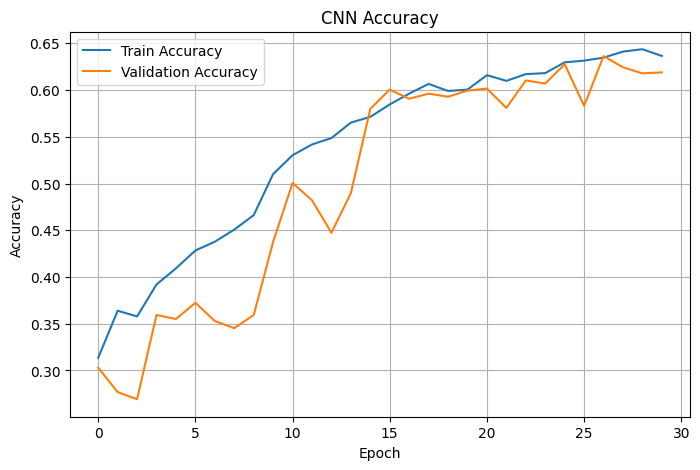

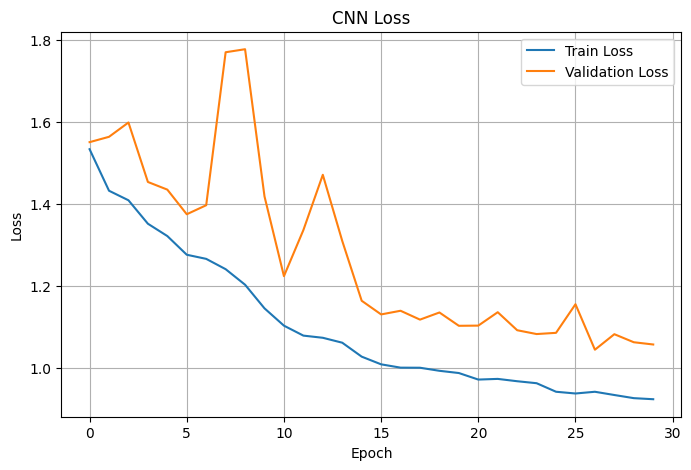

In [24]:
def plot_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_cnn, "CNN")

In [25]:
def evaluate_confusion_matrix(model, dataset, class_names, model_name, preprocess_fn=None):
    all_true  = []
    all_pred  = []
 
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_true.extend(np.argmax(labels.numpy(), axis=1))
        all_pred.extend(np.argmax(preds, axis=1))
 
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
 
    # Confusion Matrix
    cm = confusion_matrix(all_true, all_pred)
 
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix - {model_name}", fontsize=13, fontweight='bold')
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
 
    # Classification Report
    print(f"\nClassification Report - {model_name}")
    print("=" * 60)
    report = classification_report(
        all_true,
        all_pred,
        target_names=class_names,
        digits=4
    )
    print(report)
 
    # Ringkasan per metrik
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    acc  = accuracy_score(all_true, all_pred)
    prec = precision_score(all_true, all_pred, average='weighted', zero_division=0)
    rec  = recall_score(all_true, all_pred, average='weighted', zero_division=0)
    f1   = f1_score(all_true, all_pred, average='weighted', zero_division=0)
 
    print(f"{'Metric':<20} {'Value':>10}")
    print("-" * 32)
    print(f"{'Accuracy':<20} {acc:>10.4f}")
    print(f"{'Precision (weighted)':<20} {prec:>10.4f}")
    print(f"{'Recall (weighted)':<20} {rec:>10.4f}")
    print(f"{'F1-Score (weighted)':<20} {f1:>10.4f}")
 
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm
    }

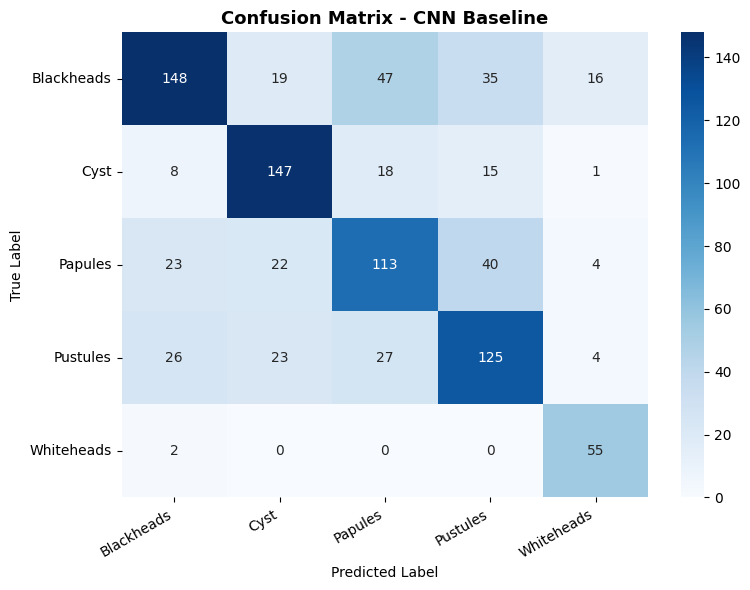


Classification Report - CNN Baseline
              precision    recall  f1-score   support

  Blackheads     0.7150    0.5585    0.6271       265
        Cyst     0.6967    0.7778    0.7350       189
     Papules     0.5512    0.5594    0.5553       202
    Pustules     0.5814    0.6098    0.5952       205
  Whiteheads     0.6875    0.9649    0.8029        57

    accuracy                         0.6405       918
   macro avg     0.6464    0.6941    0.6631       918
weighted avg     0.6436    0.6405    0.6373       918

Metric                    Value
--------------------------------
Accuracy                 0.6405
Precision (weighted)     0.6436
Recall (weighted)        0.6405
F1-Score (weighted)      0.6373


In [26]:
cnn_metrics = evaluate_confusion_matrix(
    best_cnn_model, test_cnn, class_names, "CNN Baseline"
)

### Transfer Learning

#### ResNet50

In [27]:
train_resnet = train_raw.map(
    lambda x, y: (resnet_preprocess(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
 
valid_resnet = valid_raw.map(
    lambda x, y: (resnet_preprocess(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)
 
test_resnet = test_raw.map(
    lambda x, y: (resnet_preprocess(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

In [28]:
def resnet50_custom(input_shape=(224, 224, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Base model ResNet50
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Freeze base model
    base_model.trainable = False

    # Functional API
    x = base_model(inputs, training=False)

    # Custom Attention Layer
    x = CustomAttentionLayer(name="custom_attention_resnet")(x)

    # Classification Head ResNet
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

    x = layers.Dense(
        512,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_512"
    )(x)
    x = layers.BatchNormalization(name="batch_norm_512")(x)
    x = layers.Dropout(0.5, name="dropout_1")(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_256"
    )(x)
    x = layers.BatchNormalization(name="batch_norm_256")(x)
    x = layers.Dropout(0.4, name="dropout_2")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="output_class"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_Acne_Classifier"
    )

    return model

In [29]:
resnet_model = resnet50_custom(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

resnet_model.summary()

Model: "ResNet50_Acne_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 custom_attention_resnet (C  (None, 7, 7, 2048)        100353    
 ustomAttentionLayer)                                            
                                                                 
 global_average_pooling (Gl  (None, 2048)              0         
 obalAveragePooling2D)                                           
                                                                 
 dense_512 (Dense)           (None, 512)               1049088   
                                                                 
 batch_norm_512 (BatchNorma  (None, 512)  

In [30]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy")
    ]
)

In [31]:
resnet_best_path = os.path.join(MODEL_DIR, "resnet50_best.keras")

resnet_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=resnet_best_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    CustomTrainingCallback()
]

In [32]:
history_resnet = resnet_model.fit(
    train_resnet,
    validation_data=valid_resnet,
    epochs=EPOCHS,
    callbacks=resnet_callbacks,
    class_weight=class_weights,
    verbose=0
)


New Best Validation Accuracy: 0.4180

Epoch 1 selesai
Train Acc  : 0.2937
Val Acc    : 0.4180
Train Loss : 2.1381
Val Loss   : 1.4825


New Best Validation Accuracy: 0.4777

Epoch 2 selesai
Train Acc  : 0.4039
Val Acc    : 0.4777
Train Loss : 1.7298
Val Loss   : 1.3951


New Best Validation Accuracy: 0.5136

Epoch 3 selesai
Train Acc  : 0.4492
Val Acc    : 0.5136
Train Loss : 1.5897
Val Loss   : 1.3501


Epoch 4 selesai
Train Acc  : 0.4903
Val Acc    : 0.4571
Train Loss : 1.4856
Val Loss   : 1.4631


New Best Validation Accuracy: 0.5765

Epoch 5 selesai
Train Acc  : 0.5194
Val Acc    : 0.5765
Train Loss : 1.4092
Val Loss   : 1.2416


Epoch 6 selesai
Train Acc  : 0.5454
Val Acc    : 0.5505
Train Loss : 1.3311
Val Loss   : 1.3154


Epoch 7 selesai
Train Acc  : 0.5590
Val Acc    : 0.5147
Train Loss : 1.2839
Val Loss   : 1.4321


New Best Validation Accuracy: 0.6439

Epoch 8 selesai
Train Acc  : 0.5817
Val Acc    : 0.6439
Train Loss : 1.2442
Val Loss   : 1.1053


New Best Validation Accur

In [33]:
best_resnet_model = keras.models.load_model(
    resnet_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

resnet_result = best_resnet_model.evaluate(
    test_resnet,
    return_dict=True
)

print("Hasil Evaluasi ResNet50:")
for key, value in resnet_result.items():
    print(f"{key}: {value:.4f}")

29/29 [==============================] - 40s 1s/step - loss: 1.0128 - accuracy: 0.7037 - top_2_accuracy: 0.8693
Hasil Evaluasi ResNet50:
loss: 1.0128
accuracy: 0.7037
top_2_accuracy: 0.8693


#### EfficientNetB0

In [34]:
train_efficientnet = train_raw.map(
    lambda x, y: (efficientnet_preprocess(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
 
valid_efficientnet = valid_raw.map(
    lambda x, y: (efficientnet_preprocess(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)
 
test_efficientnet = test_raw.map(
    lambda x, y: (efficientnet_preprocess(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)


In [35]:
def efficientnetb0_custom(input_shape=(224, 224, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape, name="input_image")

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = False

    x = base_model(inputs, training=False)

    # Custom Layer
    x = CustomAttentionLayer(name="custom_attention_efficientnet")(x)

    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_256"
    )(x)
    x = layers.BatchNormalization(name="batch_norm_256")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_128"
    )(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="output_class"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetB0_Acne_Classifier"
    )

    return model

In [36]:
efficientnet_model = efficientnetb0_custom(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

efficientnet_model.summary()

Model: "EfficientNetB0_Acne_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 custom_attention_efficient  (None, 7, 7, 1280)        62721     
 net (CustomAttentionLayer)                                      
                                                                 
 global_average_pooling (Gl  (None, 1280)              0         
 obalAveragePooling2D)                                           
                                                                 
 dense_256 (Dense)           (None, 256)               327936    
                                    

In [37]:
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy")
    ]
)

In [38]:
efficientnet_best_path = os.path.join(MODEL_DIR, "efficientnetb0_best.keras")

efficientnet_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=efficientnet_best_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    CustomTrainingCallback()
]

In [39]:
history_efficientnet = efficientnet_model.fit(
    train_efficientnet,
    validation_data=valid_efficientnet,
    epochs=EPOCHS,
    callbacks=efficientnet_callbacks,
    class_weight=class_weights,
    verbose=0
)


New Best Validation Accuracy: 0.2877

Epoch 1 selesai
Train Acc  : 0.2286
Val Acc    : 0.2877
Train Loss : 1.8045
Val Loss   : 1.6628


New Best Validation Accuracy: 0.3996

Epoch 2 selesai
Train Acc  : 0.3470
Val Acc    : 0.3996
Train Loss : 1.4981
Val Loss   : 1.6259


New Best Validation Accuracy: 0.4430

Epoch 3 selesai
Train Acc  : 0.4024
Val Acc    : 0.4430
Train Loss : 1.4442
Val Loss   : 1.5722


New Best Validation Accuracy: 0.4799

Epoch 4 selesai
Train Acc  : 0.4507
Val Acc    : 0.4799
Train Loss : 1.3443
Val Loss   : 1.5022


Epoch 5 selesai
Train Acc  : 0.4892
Val Acc    : 0.4506
Train Loss : 1.2785
Val Loss   : 1.4461


New Best Validation Accuracy: 0.5212

Epoch 6 selesai
Train Acc  : 0.5259
Val Acc    : 0.5212
Train Loss : 1.2055
Val Loss   : 1.3226


New Best Validation Accuracy: 0.5461

Epoch 7 selesai
Train Acc  : 0.5432
Val Acc    : 0.5461
Train Loss : 1.1723
Val Loss   : 1.2519


Epoch 8 selesai
Train Acc  : 0.5680
Val Acc    : 0.5407
Train Loss : 1.1337
Val Loss 

In [40]:
best_efficientnet_model = keras.models.load_model(
    efficientnet_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

efficientnet_result = best_efficientnet_model.evaluate(
    test_efficientnet,
    return_dict=True
)

print("Hasil Evaluasi EfficientNetB0:")
for key, value in efficientnet_result.items():
    print(f"{key}: {value:.4f}")

29/29 [==============================] - 17s 489ms/step - loss: 0.9319 - accuracy: 0.7092 - top_2_accuracy: 0.8856
Hasil Evaluasi EfficientNetB0:
loss: 0.9319
accuracy: 0.7092
top_2_accuracy: 0.8856


### Perbandingan

In [41]:
def get_history_summary(history):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    return {
        "Final Train Accuracy": train_acc[-1],
        "Final Val Accuracy": val_acc[-1],
        "Best Val Accuracy": max(val_acc),
        "Final Train Loss": train_loss[-1],
        "Final Val Loss": val_loss[-1],
        "Best Val Loss": min(val_loss),
        "Total Epoch": len(train_acc),
        "Train-Val Gap": train_acc[-1] - val_acc[-1]
    }


comparison_data = []

# CNN Custom
cnn_summary = get_history_summary(history_cnn)
comparison_data.append({
    "Model": "Custom CNN",
    **cnn_summary,
    "Test Accuracy": cnn_test_result["accuracy"],
    "Test Loss": cnn_test_result["loss"],
    "Test Top-2 Accuracy": cnn_test_result["top_2_accuracy"],
    "Total Parameters": best_cnn_model.count_params()
})

# ResNet50
resnet_summary = get_history_summary(history_resnet)
comparison_data.append({
    "Model": "ResNet50",
    **resnet_summary,
    "Test Accuracy": resnet_result["accuracy"],
    "Test Loss": resnet_result["loss"],
    "Test Top-2 Accuracy": resnet_result["top_2_accuracy"],
    "Total Parameters": best_resnet_model.count_params()
})


# EfficientNetB0
efficientnet_summary = get_history_summary(history_efficientnet)
comparison_data.append({
    "Model": "EfficientNetB0",
    **efficientnet_summary,
    "Test Accuracy": efficientnet_result["accuracy"],
    "Test Loss": efficientnet_result["loss"],
    "Test Top-2 Accuracy": efficientnet_result["top_2_accuracy"],
    "Total Parameters": best_efficientnet_model.count_params()
})


comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Final Train Accuracy,Final Val Accuracy,Best Val Accuracy,Final Train Loss,Final Val Loss,Best Val Loss,Total Epoch,Train-Val Gap,Test Accuracy,Test Loss,Test Top-2 Accuracy,Total Parameters
0,Custom CNN,0.636429,0.618892,0.636265,0.924325,1.057652,1.044918,30,0.017537,0.640523,1.074176,0.839869,495942
1,ResNet50,0.697984,0.707926,0.712269,0.981390,0.987628,0.983163,25,-0.009942,0.703704,1.012839,0.869281,24872838
2,EfficientNetB0,0.790857,0.701411,0.712269,0.731468,0.918404,0.885008,30,0.089445,0.709150,0.931856,0.885621,4474793


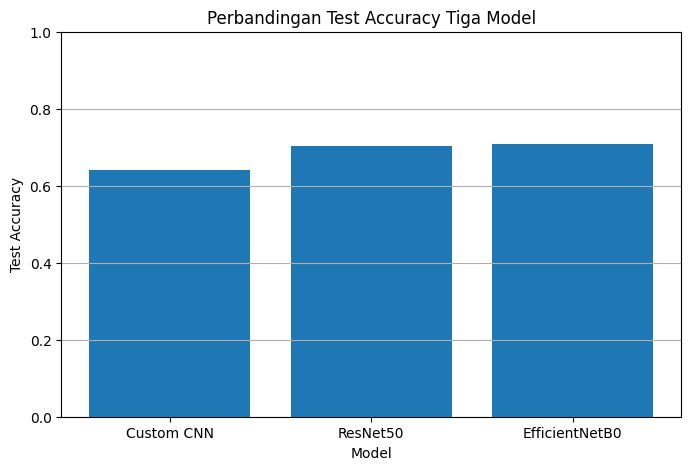

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Perbandingan Test Accuracy Tiga Model")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

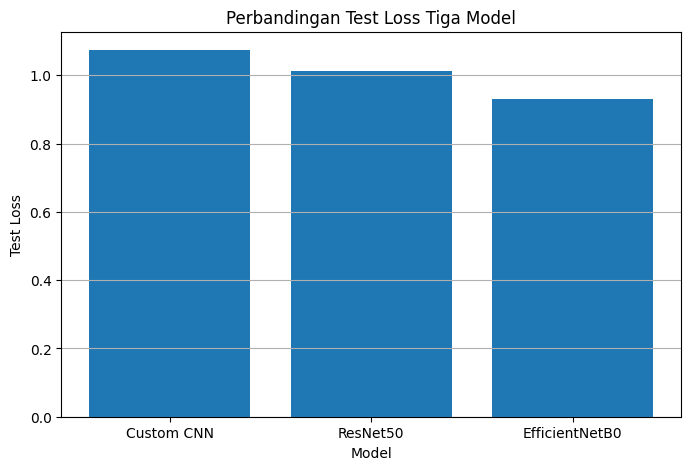

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Loss"])
plt.title("Perbandingan Test Loss Tiga Model")
plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.grid(axis="y")
plt.show()

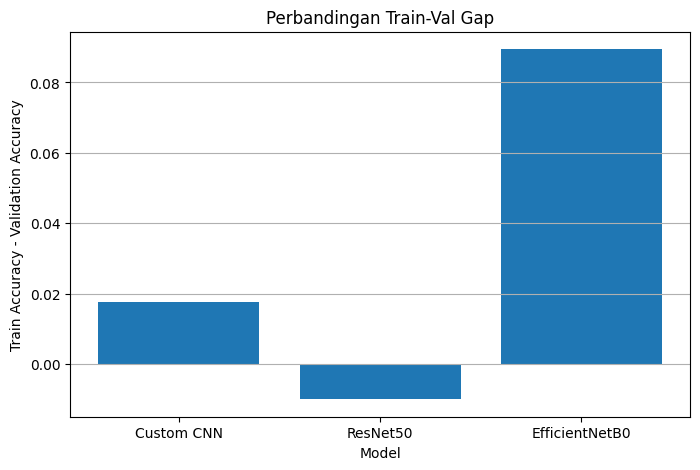

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Train-Val Gap"])
plt.title("Perbandingan Train-Val Gap")
plt.xlabel("Model")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.grid(axis="y")
plt.show()

### Fine Tune

In [45]:
best_resnet_model = keras.models.load_model(
    resnet_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

In [46]:
base_model = None

for layer in best_resnet_model.layers:
    if isinstance(layer, keras.Model) and "resnet" in layer.name.lower():
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: resnet50


In [47]:
base_model.trainable = True

for layer in base_model.layers:
    # Freeze semua layer
    layer.trainable = False

for layer in base_model.layers:
    # Unfreeze block akhir
    if layer.name.startswith("conv5_"):
        layer.trainable = True

    # BatchNormalization tetep freeze
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [48]:
trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]

print("Jumlah layer ResNet yang trainable:", len(trainable_layers))
print(trainable_layers[:10])

Jumlah layer ResNet yang trainable: 22
['conv5_block1_1_conv', 'conv5_block1_1_relu', 'conv5_block1_2_conv', 'conv5_block1_2_relu', 'conv5_block1_0_conv', 'conv5_block1_3_conv', 'conv5_block1_add', 'conv5_block1_out', 'conv5_block2_1_conv', 'conv5_block2_1_relu']


In [49]:
best_resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

In [50]:
resnet_finetune_best_path = os.path.join(MODEL_DIR, "resnet50_finetuned_best.keras")

resnet_finetune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=resnet_finetune_best_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    CustomTrainingCallback()
]

In [51]:
history_resnet_finetune = best_resnet_model.fit(
    train_resnet,
    validation_data=valid_resnet,
    epochs=15,
    callbacks=resnet_finetune_callbacks,
    class_weight=class_weights,
    verbose=0
)


New Best Validation Accuracy: 0.6873

Epoch 1 selesai
Train Acc  : 0.6901
Val Acc    : 0.6873
Train Loss : 1.0031
Val Loss   : 1.0391


New Best Validation Accuracy: 0.6982

Epoch 2 selesai
Train Acc  : 0.6911
Val Acc    : 0.6982
Train Loss : 0.9802
Val Loss   : 1.0164


New Best Validation Accuracy: 0.7296

Epoch 3 selesai
Train Acc  : 0.7045
Val Acc    : 0.7296
Train Loss : 0.9471
Val Loss   : 0.9530


Epoch 4 selesai
Train Acc  : 0.7351
Val Acc    : 0.7231
Train Loss : 0.9069
Val Loss   : 0.9696


New Best Validation Accuracy: 0.7383

Epoch 5 selesai
Train Acc  : 0.7419
Val Acc    : 0.7383
Train Loss : 0.8985
Val Loss   : 0.9179


New Best Validation Accuracy: 0.7709

Epoch 6 selesai
Train Acc  : 0.7523
Val Acc    : 0.7709
Train Loss : 0.8819
Val Loss   : 0.8802


Epoch 7 selesai
Train Acc  : 0.7642
Val Acc    : 0.7416
Train Loss : 0.8535
Val Loss   : 0.9506


Epoch 8 selesai
Train Acc  : 0.7703
Val Acc    : 0.7666
Train Loss : 0.8337
Val Loss   : 0.8714


New Best Validation Accur

In [52]:
best_resnet_finetuned_model = keras.models.load_model(
    resnet_finetune_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

resnet_finetune_result = best_resnet_finetuned_model.evaluate(
    test_resnet,
    return_dict=True
)

print("Hasil Evaluasi ResNet50 Fine-Tuned:")
for key, value in resnet_finetune_result.items():
    print(f"{key}: {value:.4f}")

29/29 [==============================] - 39s 1s/step - loss: 0.7926 - accuracy: 0.8366 - top_2_accuracy: 0.9325 - mae: 0.1054
Hasil Evaluasi ResNet50 Fine-Tuned:
loss: 0.7926
accuracy: 0.8366
top_2_accuracy: 0.9325
mae: 0.1054


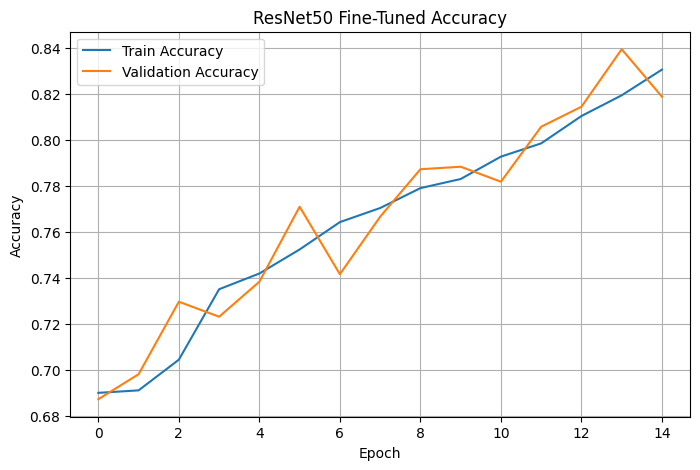

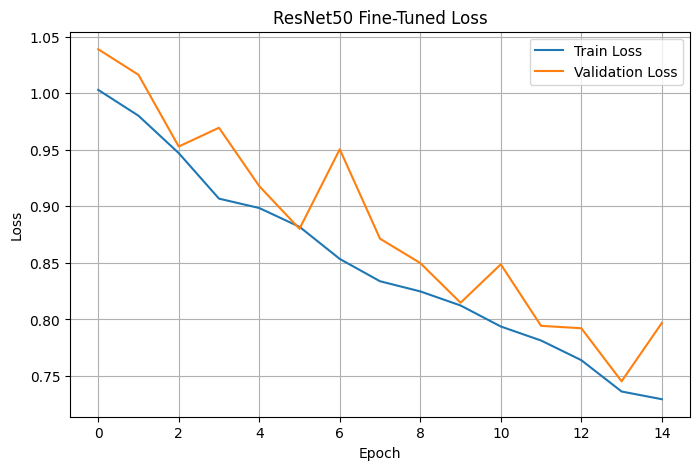

In [53]:
plot_history(history_resnet_finetune, "ResNet50 Fine-Tuned")

Evaluasi Confusion Matrix: ResNet50 Fine-Tune


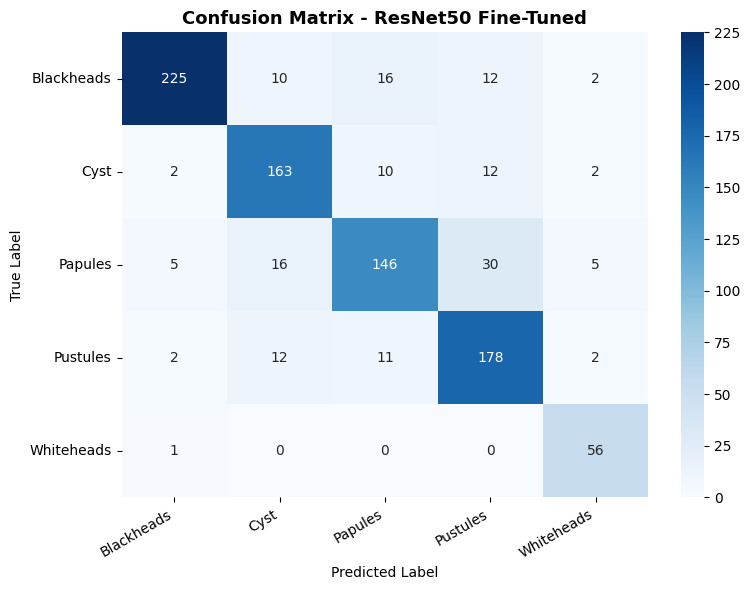


Classification Report - ResNet50 Fine-Tuned
              precision    recall  f1-score   support

  Blackheads     0.9574    0.8491    0.9000       265
        Cyst     0.8109    0.8624    0.8359       189
     Papules     0.7978    0.7228    0.7584       202
    Pustules     0.7672    0.8683    0.8146       205
  Whiteheads     0.8358    0.9825    0.9032        57

    accuracy                         0.8366       918
   macro avg     0.8339    0.8570    0.8424       918
weighted avg     0.8421    0.8366    0.8368       918

Metric                    Value
--------------------------------
Accuracy                 0.8366
Precision (weighted)     0.8421
Recall (weighted)        0.8366
F1-Score (weighted)      0.8368


In [54]:
print("Evaluasi Confusion Matrix: ResNet50 Fine-Tune")
resnet_ft_metrics = evaluate_confusion_matrix(
    best_resnet_finetuned_model,
    test_resnet,
    class_names,
    "ResNet50 Fine-Tuned"
)

#### Efficientnetb0

In [56]:
best_efficientnet_model = keras.models.load_model(
    efficientnet_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

In [57]:
base_model_eff = None

for layer in best_efficientnet_model.layers:
    if isinstance(layer, keras.Model) and "efficientnet" in layer.name.lower():
        base_model_eff = layer
        break

print("Base model:", base_model_eff.name)

Base model: efficientnetb0


In [62]:
for layer in base_model_eff.layers:
    print(layer.name)

input_2
rescaling_1
normalization
rescaling_2
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand
b

In [65]:
# Unfreeze base model 
base_model_eff.trainable = True

# Freeze semua layer
for layer in base_model_eff.layers:
    layer.trainable = False

# Unfreeze block6, block7, dan top
for layer in base_model_eff.layers:
    if (layer.name.startswith("block6") or 
        layer.name.startswith("block7") or 
        layer.name.startswith("top_")):
        layer.trainable = True

    # BatchNormalization freeze
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [66]:
trainable_layers_eff = [layer.name for layer in base_model_eff.layers if layer.trainable]

print("Jumlah layer EfficientNetB0 yang trainable:", len(trainable_layers_eff))
print(trainable_layers_eff[:10])

Jumlah layer EfficientNetB0 yang trainable: 59
['block6a_expand_conv', 'block6a_expand_activation', 'block6a_dwconv_pad', 'block6a_dwconv', 'block6a_activation', 'block6a_se_squeeze', 'block6a_se_reshape', 'block6a_se_reduce', 'block6a_se_expand', 'block6a_se_excite']


In [70]:
best_efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

In [71]:
efficientnet_finetune_best_path = os.path.join(MODEL_DIR, "efficientnetb0_finetuned_best.keras")

efficientnet_finetune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=efficientnet_finetune_best_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    CustomTrainingCallback()
]

In [72]:
history_efficientnet_finetune = best_efficientnet_model.fit(
    train_efficientnet,
    validation_data=valid_efficientnet,
    epochs=15,
    callbacks=efficientnet_finetune_callbacks,
    class_weight=class_weights,
    verbose=0
)



New Best Validation Accuracy: 0.7307

Epoch 1 selesai
Train Acc  : 0.7891
Val Acc    : 0.7307
Train Loss : 0.7390
Val Loss   : 0.8486


New Best Validation Accuracy: 0.7394

Epoch 2 selesai
Train Acc  : 0.7991
Val Acc    : 0.7394
Train Loss : 0.7153
Val Loss   : 0.8537


New Best Validation Accuracy: 0.7590

Epoch 3 selesai
Train Acc  : 0.7984
Val Acc    : 0.7590
Train Loss : 0.7124
Val Loss   : 0.8132


Epoch 4 selesai
Train Acc  : 0.8117
Val Acc    : 0.7492
Train Loss : 0.6958
Val Loss   : 0.8278


Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

New Best Validation Accuracy: 0.7600

Epoch 5 selesai
Train Acc  : 0.8161
Val Acc    : 0.7600
Train Loss : 0.6885
Val Loss   : 0.8274


Epoch 6 selesai
Train Acc  : 0.8215
Val Acc    : 0.7514
Train Loss : 0.6752
Val Loss   : 0.8381


New Best Validation Accuracy: 0.7611

Epoch 7 selesai
Train Acc  : 0.8254
Val Acc    : 0.7611
Train Loss : 0.6687
Val Loss   : 0.8101


New Best Validation Accuracy: 0.7633

Epoch 8

In [73]:
best_efficientnet_finetuned_model = keras.models.load_model(
    efficientnet_finetune_best_path,
    custom_objects={
        "CustomAttentionLayer": CustomAttentionLayer
    }
)

efficientnet_finetune_result = best_efficientnet_finetuned_model.evaluate(
    test_efficientnet,
    return_dict=True
)

print("Hasil Evaluasi EfficientNetB0 Fine-Tuned:")
for key, value in efficientnet_finetune_result.items():
    print(f"{key}: {value:.4f}")


29/29 [==============================] - 16s 473ms/step - loss: 0.8282 - accuracy: 0.7582 - top_2_accuracy: 0.9107 - mae: 0.1348
Hasil Evaluasi EfficientNetB0 Fine-Tuned:
loss: 0.8282
accuracy: 0.7582
top_2_accuracy: 0.9107
mae: 0.1348


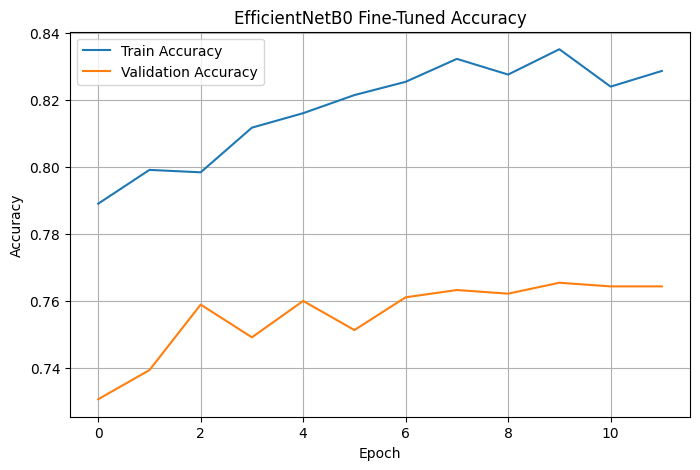

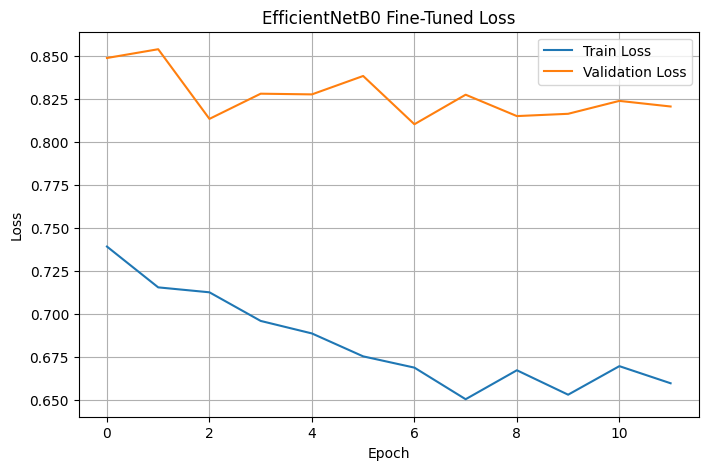

In [74]:
plot_history(history_efficientnet_finetune, "EfficientNetB0 Fine-Tuned")

Evaluasi Confusion Matrix: EfficientNetB0 Fine-Tune


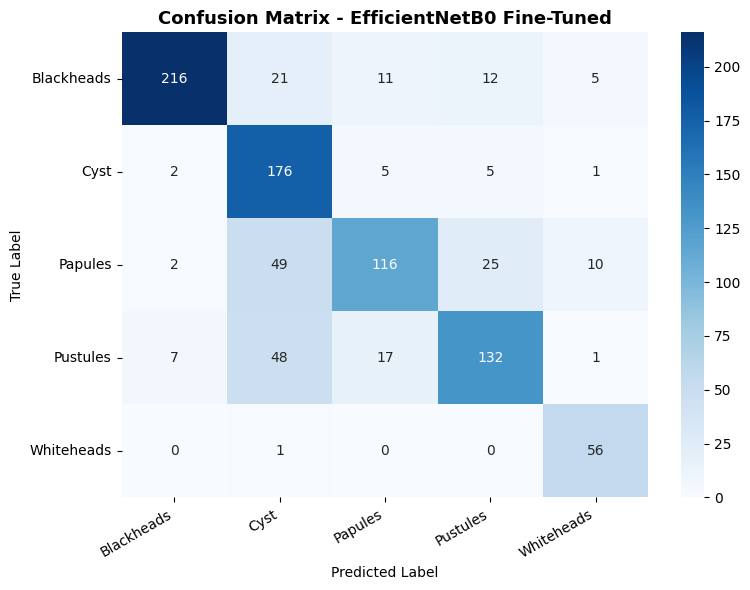


Classification Report - EfficientNetB0 Fine-Tuned
              precision    recall  f1-score   support

  Blackheads     0.9515    0.8151    0.8780       265
        Cyst     0.5966    0.9312    0.7273       189
     Papules     0.7785    0.5743    0.6610       202
    Pustules     0.7586    0.6439    0.6966       205
  Whiteheads     0.7671    0.9825    0.8615        57

    accuracy                         0.7582       918
   macro avg     0.7705    0.7894    0.7649       918
weighted avg     0.7859    0.7582    0.7577       918

Metric                    Value
--------------------------------
Accuracy                 0.7582
Precision (weighted)     0.7859
Recall (weighted)        0.7582
F1-Score (weighted)      0.7577


In [75]:
print("Evaluasi Confusion Matrix: EfficientNetB0 Fine-Tune")
efficientnet_ft_metrics = evaluate_confusion_matrix(
    best_efficientnet_finetuned_model,
    test_efficientnet,
    class_names,
    "EfficientNetB0 Fine-Tuned"
)

### Perbandingan

In [96]:
final_summary = pd.DataFrame({
    "Model": ["CNN Baseline", "ResNet50", "EfficientNetB0", "ResNet50 Fine-Tuned", "EfficientNetB0 Fine-Tuned"],
    "Test Accuracy": [
        cnn_test_result["accuracy"],
        resnet_result["accuracy"],
        efficientnet_result["accuracy"],
        resnet_finetune_result["accuracy"],
        efficientnet_finetune_result["accuracy"]
    ],
    "Test Loss": [
        cnn_test_result["loss"],
        resnet_result["loss"],
        efficientnet_result["loss"],
        resnet_finetune_result["loss"], 
        efficientnet_finetune_result["loss"]
    ]
})
 
print(final_summary.to_string(index=False))

                    Model  Test Accuracy  Test Loss
             CNN Baseline       0.640523   1.074176
                 ResNet50       0.703704   1.012839
           EfficientNetB0       0.709150   0.931856
      ResNet50 Fine-Tuned       0.836601   0.792641
EfficientNetB0 Fine-Tuned       0.758170   0.828221


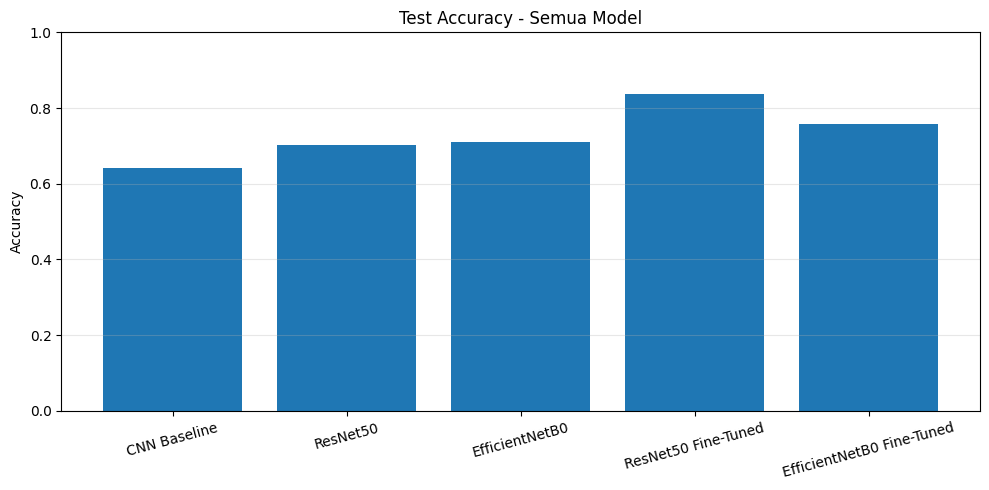

In [95]:
plt.figure(figsize=(10, 5))
x = np.arange(len(final_summary["Model"]))
plt.bar(x, final_summary["Test Accuracy"])
plt.xticks(x, final_summary["Model"], rotation=15)
plt.title("Test Accuracy - Semua Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Inference

In [80]:
final_model = keras.models.load_model(
    resnet_finetune_best_path,
    custom_objects={"CustomAttentionLayer": CustomAttentionLayer},
    compile=False
)
 
print("Model ResNet50 fine-tuned berhasil dimuat.")
print("Class names:", class_names)

Model ResNet50 fine-tuned berhasil dimuat.
Class names: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


In [89]:
def predict_acne_image(image_path, model, class_names, img_size=(224, 224)):
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)
 
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence      = predictions[0][predicted_index]
 
 
    print(f"\nHasil Prediksi")
    print(f"  Class      : {predicted_class}")
    print(f"  Confidence : {confidence:.4f}")
    print("\nProbabilitas tiap class:")
    for name, prob in zip(class_names, predictions[0]):
        print(f"  {name:<15}: {prob:.4f}")
 
    return predicted_class, confidence, predictions

In [90]:
image_path = os.path.join("test_images", "cy.jpg")
if os.path.exists(image_path):
    predict_acne_image(image_path, final_model, class_names)


Hasil Prediksi
  Class      : Cyst
  Confidence : 0.9637

Probabilitas tiap class:
  Blackheads     : 0.0017
  Cyst           : 0.9637
  Papules        : 0.0001
  Pustules       : 0.0335
  Whiteheads     : 0.0010


In [91]:
image_path = os.path.join("test_images", "blck.jpg")
if os.path.exists(image_path):
    predict_acne_image(image_path, final_model, class_names)


Hasil Prediksi
  Class      : Blackheads
  Confidence : 0.7878

Probabilitas tiap class:
  Blackheads     : 0.7878
  Cyst           : 0.0015
  Papules        : 0.0002
  Pustules       : 0.0001
  Whiteheads     : 0.2104


In [92]:
image_path = os.path.join("test_images", "papula.png")
if os.path.exists(image_path):
    predict_acne_image(image_path, final_model, class_names)


Hasil Prediksi
  Class      : Papules
  Confidence : 0.8290

Probabilitas tiap class:
  Blackheads     : 0.0834
  Cyst           : 0.0010
  Papules        : 0.8290
  Pustules       : 0.0743
  Whiteheads     : 0.0123


In [93]:
image_path = os.path.join("test_images", "pustula.jpg")
if os.path.exists(image_path):
    predict_acne_image(image_path, final_model, class_names)


Hasil Prediksi
  Class      : Pustules
  Confidence : 1.0000

Probabilitas tiap class:
  Blackheads     : 0.0000
  Cyst           : 0.0000
  Papules        : 0.0000
  Pustules       : 1.0000
  Whiteheads     : 0.0000


In [94]:
image_path = os.path.join("test_images", "white2.png")
if os.path.exists(image_path):
    predict_acne_image(image_path, final_model, class_names)


Hasil Prediksi
  Class      : Whiteheads
  Confidence : 0.9800

Probabilitas tiap class:
  Blackheads     : 0.0110
  Cyst           : 0.0011
  Papules        : 0.0048
  Pustules       : 0.0031
  Whiteheads     : 0.9800
